# Fine Tuning SAM Audio

```mermaid
flowchart TD

    subgraph Data Preparation Phase
        RawStems[Raw Instrument Stems: Bağlama and Zurna] --> DynamicMix[Dynamic Mixing Strategy]
        DynamicMix --> MixtureAudio[Complex Mixture Audio]
        DynamicMix --> TargetAudio[Isolated Ground Truth Audio]
        Prompt[Text Prompt e.g., 'bağlama solo'] --> Tuple[Create Training Tuple]
        MixtureAudio --> Tuple
        TargetAudio --> Tuple
    end

    subgraph Latent Compression Phase DAC-VAE
        Tuple --> LoadVAE[Extract SAM Audio Built-in VAE]
        LoadVAE --> FreezeVAE[Freeze VAE Weights: No Gradients]
        FreezeVAE --> EncodeLatents[Encode Audio to Continuous Latents]
        EncodeLatents --> LatentTensors[Output 128-channel .pt Tensors]
    end

    subgraph Custom PyTorch Setup Phase
        LatentTensors --> CustomDataset[Build Custom PyTorch Dataset Class]
        CustomDataset --> LoadBase[Load Frozen Base: facebook/sam-audio-large]
        LoadBase --> InjectLoRA[Wrap with PEFT/LoRA: wq, wv]
        InjectLoRA --> EnableGrads[Enable Checkpointing & Input Requires Grad]
        EnableGrads --> LoadScheduler[Init diffusers FlowMatchEulerDiscreteScheduler]
        LoadScheduler --> Accelerate[Setup accelerate for VRAM Management]
    end

    subgraph Custom LoRA Flow-Matching Training Loop
        Accelerate --> SqueezeBatch[Fix Double Batch: Apply .squeeze 1 & .transpose]
        SqueezeBatch --> MetaTrick[Meta's Trick: Duplicate 128 channels to 256 via torch.cat]
        MetaTrick --> TimeSample[Sample Random Continuous Timestep: t]
        TimeSample --> AddNoise[Noise 256-channel Target Latent to create state: x_t_256]
        AddNoise --> ManualWedge[Manual Tensor Wedge: x_t_256.requires_grad_ True]
        ManualWedge --> ForwardPass[Forward Pass: DiT conditioned on x_t, t, Mixture, Text]
        ForwardPass --> CalcLoss[Calculate Vector Field MSE Loss in 256-channel Space]
        CalcLoss --> Backprop[Backpropagate Gradients strictly to LoRA Adapters]
        Backprop --> SaveAdapter[Export adapter_model.safetensors]
    end

    subgraph Inference and Validation Phase
        SaveAdapter --> DeployModel[Load Base Model + Injected LoRA Adapter]
        DeployModel --> InputNovel[Input Novel Unseen Audio Mixture & Prompt]
        InputNovel --> DiTSeparation[DiT Generates Continuous 256-channel Target Latents]
        DiTSeparation --> SliceLatents[Slice Latents Back to 128 Channels]
        SliceLatents --> DecodeAudio[DAC-VAE Decoder Reconstructs Isolated Audio]
    end
```

## Load SAM Audio and Processor

In [1]:
import torch
from sam_audio import SAMAudio, SAMAudioProcessor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_ID = "facebook/sam-audio-base"  # base model

processor = SAMAudioProcessor.from_pretrained(MODEL_ID)
base_model = SAMAudio.from_pretrained(MODEL_ID)
base_model = base_model.to(device=device, dtype=torch.bfloat16)

base_model.eval()  # Freeze model

/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.11.0+cu130)
    Python  3.10.19 (you have 3.11.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be

SAMAudio(
  (audio_codec): DACVAE(
    (encoder): Encoder(
      (block): Sequential(
        (0): NormConv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,))
        (1): EncoderBlock(
          (block): Sequential(
            (0): ResidualUnit(
              (block): Sequential(
                (0): Snake1d()
                (1): NormConv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
                (2): Snake1d()
                (3): NormConv1d(64, 64, kernel_size=(1,), stride=(1,))
              )
            )
            (1): ResidualUnit(
              (block): Sequential(
                (0): Snake1d()
                (1): NormConv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(9,), dilation=(3,))
                (2): Snake1d()
                (3): NormConv1d(64, 64, kernel_size=(1,), stride=(1,))
              )
            )
            (2): ResidualUnit(
              (block): Sequential(
                (0): Snake1d()
                (1): NormConv1d(64, 64, 

## Latent Compression

In [3]:
import os
import pandas as pd
import torch
import torchaudio

# Load metadata
metadata_path = '../data/mixed/metadata.csv'
df = pd.read_csv(metadata_path)

# Initialize paths for latents
dirs = {
    'mixed': '../data/latents/mixed/',
    'baglama': '../data/latents/baglama/',
    'zurna': '../data/latents/zurna/'
}
for d in dirs.values():
    os.makedirs(d, exist_ok=True)

In [4]:
# Load frozen builtin VAE model
vae = base_model.audio_codec

vae.eval()  # Freeze VAE
for param in vae.parameters():
    param.requires_grad = False


def process_audio(file_path, model_sample_rate):
    try:
        wav, sample_rate = torchaudio.load(file_path)

        # Ensure [C, T]
        if wav.ndim == 1:
            wav = wav.unsqueeze(0)  # [1, T]
        elif wav.ndim == 2 and wav.shape[0] > wav.shape[1]:
            wav = wav.transpose(0, 1)  # [T, C] -> [C, T]

        wav = wav.float()

        orig_sr = int(sample_rate)
        target_sr = int(processor.audio_sampling_rate)

        # Resample
        if sample_rate != model_sample_rate:
            wav = torchaudio.functional.resample(wav, orig_sr, target_sr)

        # Mono
        wav = wav.mean(0, keepdim=True)  # [1, T]

        # Expected shape is batch x 1 x samples
        wav = wav.unsqueeze(0).to(device=device, dtype=next(base_model.parameters()).dtype)

        return wav
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None


In [5]:
from tqdm.auto import tqdm

print("Encoding audio to latents...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    mixed_file = row['file_name']
    zurna_source = row['zurna_source']
    baglama_source = row['baglama_source']

    # Resolve paths
    mixed_path = os.path.join('../data/mixed/', mixed_file)
    zurna_path = os.path.join('../data/processed/zurna/', zurna_source)
    baglama_path = os.path.join('../data/processed/baglama/', baglama_source)

    # Process and encode each category
    file_mappings = [
        ('mixed', mixed_path, mixed_file),
        ('zurna', zurna_path, zurna_source),
        ('baglama', baglama_path, baglama_source)
    ]

    for label, audio_path, filename in file_mappings:
        base_name = filename.replace('.wav', '.pt')
        out_path = os.path.join(dirs[label], base_name)

        # Skip if already encoded
        if os.path.exists(out_path):
            continue

        wav_input = process_audio(audio_path, processor.audio_sampling_rate)
        if wav_input is not None:
            with torch.no_grad():
                encoded = vae(wav_input)
            torch.save(encoded.cpu(), out_path)

print("Latent encoding complete!")

Encoding audio to latents...


100%|██████████| 60/60 [00:00<00:00, 6975.78it/s]

Latent encoding complete!


## Setup PEFT/LoRA Fine-Tune

In [6]:
base_model.text_encoder.requires_grad_(False)

with torch.no_grad():
    text_features, text_mask = base_model.text_encoder(['zurna'])

print("Text embeddings shape:", text_features.shape)

Text embeddings shape: torch.Size([1, 4, 768])


### Custom Dataset

In [7]:
from torch.utils.data import Dataset
import torch
import pandas as pd
import os

class TurkishMusicDataset(Dataset):
    def __init__(self, metadata_csv, latent_dirs, text_encoder):
        self.df = pd.read_csv(metadata_csv)
        self.latent_dirs = latent_dirs
        self.instruments = ['zurna', 'baglama']

        # Precompute embeddings once per instrument
        self.text_embeddings = {}
        with torch.no_grad():
            for inst in self.instruments:
                features, mask = text_encoder([inst])
                # Squeeze out the batch dimension to store single items
                self.text_embeddings[inst] = {
                    'features': features.squeeze(0),
                    'mask': mask.squeeze(0)
                }

    def __len__(self):
        # We double the length because each row yields two samples (zurna and baglama)
        return len(self.df) * 2

    def __getitem__(self, idx):
        # Determine which row and parameter to use based on index
        row_idx = idx // 2
        instrument = self.instruments[idx % 2]

        row = self.df.iloc[row_idx]

        # Load mix latent
        mixed_filename = row['file_name']
        mixed_base = mixed_filename.replace('.wav', '.pt')
        mix_latent = torch.load(os.path.join(self.latent_dirs, 'mixed', mixed_base)).squeeze(0)

        # Load target latent
        target_filename = row[f'{instrument}_source']
        target_base = target_filename.replace('.wav', '.pt')
        target_latent = torch.load(os.path.join(self.latent_dirs, instrument, target_base)).squeeze(0)

        return {
            'mix_latent': mix_latent,
            'target_latent': target_latent,
            'text_features': self.text_embeddings[instrument]['features'],
            'text_mask': self.text_embeddings[instrument]['mask'],
            'instrument': instrument
        }

In [8]:
tmd = TurkishMusicDataset('../data/mixed/metadata.csv', '../data/latents/', base_model.text_encoder)
print(f"Dataset size: {len(tmd)}")
sample = tmd[0]
print("Sample keys:", sample.keys())
print(f"Instrument: {sample['instrument']}")

Dataset size: 120
Sample keys: dict_keys(['mix_latent', 'target_latent', 'text_features', 'text_mask', 'instrument'])
Instrument: zurna


In [9]:
sample['mix_latent'].shape, sample['target_latent'].shape, sample['text_features'].shape, sample['text_mask'].shape

(torch.Size([128, 125]),
 torch.Size([128, 125]),
 torch.Size([4, 768]),
 torch.Size([4]))

In [10]:
BATCH_SIZE = 4

In [11]:
from torch.utils.data import random_split, DataLoader
import torch

# 1. Define the size of the splits (e.g., 80% for training, 20% for testing)
train_size = int(0.8 * len(tmd))
test_size = len(tmd) - train_size

# 2. Split the dataset (using a generator for reproducibility)
train_dataset, test_dataset = random_split(
    tmd,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Optional: ensures the same split every run
)

print(f"Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

Train size: 96 | Test size: 24


In [17]:
from torch.nn.utils.rnn import pad_sequence

def pad_collate_fn(batch):
    # Extract the audio latents (They are already the same size, so standard stack works)
    mix_latents = torch.stack([item["mix_latent"] for item in batch])
    target_latents = torch.stack([item["target_latent"] for item in batch])

    # Extract the variable-length text features and masks
    text_feats = [item["text_features"] for item in batch]
    text_masks = [item["text_mask"] for item in batch]

    # Dynamically pad the text tensors with 0s to match the longest one in the batch
    padded_text_feats = pad_sequence(text_feats, batch_first=True, padding_value=0.0)
    padded_text_masks = pad_sequence(text_masks, batch_first=True, padding_value=0)

    return {
        "mix_latent": mix_latents,
        "target_latent": target_latents,
        "text_features": padded_text_feats,
        "text_mask": padded_text_masks
    }

In [18]:
# 3. Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=pad_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_collate_fn)

### Wrap with PEFT/LoRA

In [19]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    # The developers of SAMAudio named the attention layers in their DiT (the DiT handles the actual latent generation) wq and wv
    target_modules=["wq", "wv"],
    lora_dropout=0.05,
    bias="none"
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 4,194,304 || all params: 6,468,359,530 || trainable%: 0.0648


### Initialize Flow Matching Scheduler and Accelerate

In [20]:
NUM_EPOCHS = 100

In [21]:
from diffusers import FlowMatchEulerDiscreteScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from accelerate import Accelerator
from torch.optim import AdamW
import math

# initialize flow-matching scheduler
scheduler = FlowMatchEulerDiscreteScheduler(
    num_train_timesteps=1000,
    shift=1.0 # standard shift value for flow matching
)

# initialize accelerator for vram and device management
accelerator = Accelerator(
    gradient_accumulation_steps=4,
    mixed_precision="bf16"
)

optimizer = AdamW(peft_model.parameters(), lr=1e-4)

# CRITICAL: Because we are accumulating gradients over 16 batches,
# the optimizer only takes a "step" once every 16 forward passes.
num_update_steps_per_epoch = math.ceil(len(train_loader) / accelerator.gradient_accumulation_steps)
max_train_steps = NUM_EPOCHS * num_update_steps_per_epoch

# 2. Define Warmup Steps
# A standard rule of thumb for LoRA is warming up for 5% to 10% of total training steps.
num_warmup_steps = int(max_train_steps * 0.10)

# 3. Initialize the Scheduler
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=max_train_steps
)

# Pass everything to accelerator.prepare
peft_model, optimizer, train_loader, test_loader, lr_scheduler = accelerator.prepare(
    peft_model, optimizer, train_loader, test_loader, lr_scheduler
)

print("Flow-Matching Scheduler and Accelerator Initialized!")
print(f"Total Training Steps: {max_train_steps}")
print(f"Warmup Steps: {num_warmup_steps}")

Flow-Matching Scheduler and Accelerator Initialized!
Total Training Steps: 600
Warmup Steps: 60


## Custom LoRA Flow-Matching Training Loop

In [22]:
import inspect

# Inspect the forward method of the underlying base model
signature = inspect.signature(base_model.forward)

print("SAM Audio Forward Signature:")
for param in signature.parameters.values():
    print(f"- {param.name}: {param.default}")

SAM Audio Forward Signature:
- noisy_audio: <class 'inspect._empty'>
- audio_features: <class 'inspect._empty'>
- text_features: <class 'inspect._empty'>
- time: <class 'inspect._empty'>
- masked_video_features: None
- text_mask: None
- anchor_ids: None
- anchor_alignment: None
- audio_pad_mask: None


In [23]:
import torch
import torch.nn.functional as F

# Ensure the frozen base model is in eval mode, but PEFT adapters are training
peft_model.train()

for epoch in range(NUM_EPOCHS):
    # train_dataloader yields the Tuple: Mixture, Target, Text Embeddings
    for step, batch in enumerate(train_loader):

        # accelerate.accumulate handles the 16-step gradient hold for your T4
        with accelerator.accumulate(peft_model):

            # 1. Unpack the Pre-Computed Tensors
            mixture_latent = batch["mix_latent"].transpose(1, 2)         # Conditioner 1: [Batch, 125, 128]
            target_latent = batch["target_latent"].transpose(1, 2)           # Ground Truth x_1: [Batch, 125, 128]
            text_features = batch["text_features"]    # Conditioner 2: Frozen Embeddings
            text_mask = batch["text_mask"]

            # batch_size = target_latent.shape[0]

            # 2. Generate Pure Gaussian Noise (x_0)
            # noise = torch.randn_like(target_latent)

            # 3. Time Sampling
            # You randomly select a continuous timestep (t) between 0 and 1[cite: 1062].
            t = torch.rand((BATCH_SIZE,), device=accelerator.device)
            t_expanded = t.view(BATCH_SIZE, 1, 1) # Reshape for tensor broadcasting

            # 4. Noising the Destination (The Probability Path)
            # You use the scheduler to dynamically add noise to your Target Latent, creating a degraded state (x_t)[cite: 1063].
            # In standard Flow-Matching, this is a straight mathematical line[cite: 1096].
            # x_t = (1 - t_expanded) * noise + t_expanded * target_latent

            # additional step, Meta's trick (https://github.com/facebookresearch/sam-audio/blob/68b48d48fff1ad776d3afefbe634eb5f5d60ba7b/sam_audio/model/model.py#L184)
            mixture_256 = torch.cat([mixture_latent, mixture_latent], dim=-1)
            target_256 = torch.cat([target_latent, target_latent], dim=-1)
            # generate Noise and Noisy State in the 256-dimensional space
            noise_256 = torch.randn_like(target_256)
            x_t_256 = (1 - t_expanded) * noise_256 + t_expanded * target_256

            # 5. The Forward Pass
            # Wrap the forward pass to automatically handle mixed precision casting
            with accelerator.autocast():
                # You feed the noisy state (x_t), the timestep (t), and your two completely clean conditioners (the Mixture Latent and the Text Prompt) into your peft_model[cite: 1064].
                predicted_velocity = peft_model(
                    noisy_audio=x_t_256,
                    time=t,
                    audio_features=mixture_256,
                    text_features=text_features,
                    text_mask=text_mask
                )

                # 6. Calculate the True Vector Field
                # Flow-matching models predict the trajectory pointing from noise to target.
                true_velocity = target_256 - noise_256

                # 7. Vector Field Discrepancy Loss
                # Calculate the MSE between the predicted trajectory and the true trajectory[cite: 1107].
                loss = F.mse_loss(predicted_velocity, true_velocity)

            # 8. The Update
            # Push the gradients back strictly to the tiny q_proj and v_proj LoRA weights[cite: 1066].
            accelerator.backward(loss)

            # Optimizer automatically respects the gradient_accumulation_steps=16 we set earlier
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

        # Optional: Print loss to verify convergence
        if step % 50 == 0:
            print(f"Epoch {epoch} | Step {step} | Flow-Matching Loss: {loss.item()}")

Epoch 0 | Step 0 | Flow-Matching Loss: 1.1025034189224243
Epoch 1 | Step 0 | Flow-Matching Loss: 0.9344671964645386
Epoch 2 | Step 0 | Flow-Matching Loss: 0.798416793346405
Epoch 3 | Step 0 | Flow-Matching Loss: 1.0226304531097412
Epoch 4 | Step 0 | Flow-Matching Loss: 1.0023950338363647
Epoch 5 | Step 0 | Flow-Matching Loss: 1.207553505897522
Epoch 6 | Step 0 | Flow-Matching Loss: 0.9493738412857056
Epoch 7 | Step 0 | Flow-Matching Loss: 0.7478749752044678
Epoch 8 | Step 0 | Flow-Matching Loss: 0.607440710067749
Epoch 9 | Step 0 | Flow-Matching Loss: 0.4775776267051697
Epoch 10 | Step 0 | Flow-Matching Loss: 0.7372839450836182
Epoch 11 | Step 0 | Flow-Matching Loss: 0.5604350566864014
Epoch 12 | Step 0 | Flow-Matching Loss: 0.5891315937042236
Epoch 13 | Step 0 | Flow-Matching Loss: 0.44619220495224
Epoch 14 | Step 0 | Flow-Matching Loss: 0.6727733612060547
Epoch 15 | Step 0 | Flow-Matching Loss: 0.6984169483184814
Epoch 16 | Step 0 | Flow-Matching Loss: 0.4250407814979553
Epoch 17 | S

In [24]:
import os

# 1. Ensure all GPUs have finished their final calculations
# (Crucial if you scaled up to multi-GPU, but a good safety habit on single GPUs too)
accelerator.wait_for_everyone()

# 2. Define your output directory
save_directory = "./turkish_sam_audio_lora"
os.makedirs(save_directory, exist_ok=True)

# 3. Unwrap and Save
# accelerator.unwrap_model removes any PyTorch Distributed Data Parallel wrappers.
# save_pretrained tells PEFT to extract strictly the q_proj and v_proj matrices.
unwrapped_model = accelerator.unwrap_model(peft_model)
unwrapped_model.save_pretrained(
    save_directory,
    safe_serialization=True # Forces the export to the ultra-secure .safetensors format
)

print(f"LoRA adapters successfully saved to: {save_directory}")

LoRA adapters successfully saved to: ./turkish_sam_audio_lora


## Inference and Validation

In [25]:
import torch
import torchaudio
import os

peft_model.eval()
vae.eval()

output_dir = "./turkish_validation_stems"
os.makedirs(output_dir, exist_ok=True)

In [26]:
# Set the standard steps for high-fidelity flow-matching inference
NUM_INFERENCE_STEPS = 50

In [28]:
batch["mix_latent"].shape

torch.Size([4, 128, 125])

In [41]:
print(f"Initiating Validation Phase on {len(test_loader)} samples...")

target_dtype = torch.bfloat16  # Use the same dtype as the model for consistency and performance

# --- 2. The Inference Loop ---
with torch.no_grad(): # Completely shut off the autograd engine
    for step, batch in enumerate(test_loader):
        # Unpack the test batch and apply the exact same dimensional fixes used in training
        mixture_128 = batch["mix_latent"].to(accelerator.device, dtype=target_dtype).squeeze(1).transpose(1, 2)
        text_features = batch["text_features"].to(accelerator.device, dtype=target_dtype)
        text_mask = batch["text_mask"].to(accelerator.device)

        # Capture the dynamic batch size and sequence length
        batch_size = mixture_128.shape[0] # This will be 4
        seq_len = mixture_128.shape[1]    # This will be 125

        # Meta's Trick: Duplicate 128 channels to 256 via torch.cat [cite: 2094]
        mixture_256 = torch.cat([mixture_128, mixture_128], dim=-1)

        latents = torch.randn((batch_size, seq_len, 256), device=accelerator.device, dtype=mixture_256.dtype)

        # ---------------------------------------------------------
        # --- 3. Custom Native Euler Denoising Path ---
        # Diffusers schedulers expect reverse paths (like 1000 to 0).
        # For flow matching, we step uniformly from t=0.0 (Noise) to 1.0 (Target).
        # ---------------------------------------------------------

        NUM_INFERENCE_STEPS = 50
        dt = 1.0 / NUM_INFERENCE_STEPS

        for step_idx in range(NUM_INFERENCE_STEPS):
            # Calculate the current continuous time t in [0.0, 1.0)
            t_val = step_idx * dt
            time_input = torch.full((batch_size,), t_val, device=accelerator.device, dtype=target_dtype)

            # Forward Pass: Predict the velocity field mapping noise -> target
            predicted_velocity = peft_model(
                noisy_audio=latents,
                time=time_input,
                audio_features=mixture_256,
                text_features=text_features,
                text_mask=text_mask
            )

            # Step forward along the mathematical flow trajectory (x_t+dt = x_t + v * dt)
            latents = latents + predicted_velocity * dt

        # --- 4. Slicing and Decoding ---
        # Slice Latents Back to 128 Channels [cite: 2096]
        # Because your custom training loop forced the model to only care about the first 128 channels, this executes flawlessly [cite: 2105, 2106]
        target_128 = latents[:, :, :128].transpose(1, 2)

        target_128 = target_128.to(dtype=target_dtype)

        # Reconstruct the continuous latent vectors back into audible waveforms
        separated_audio = vae.decode(target_128)

        # --- 5. Export the Final Audio ---
        # The tensor is [4, 1, 240000]. We loop 4 times.
        for i in range(batch_size):

            # Slice out a single track: Shape goes from [4, 1, 240000] -> [1, 240000]
            single_track = separated_audio[i].cpu()

            # Calculate a unique global index for the file name so they don't overwrite
            global_idx = (step * batch_size) + i
            output_path = os.path.join(output_dir, f"validation_stem_{global_idx}.wav")

            # Save the clean 2D tensor
            torchaudio.save(
                output_path,
                src=single_track,
                sample_rate=vae.sample_rate
            )

        print(f"Batch {step} complete: Separated {batch_size} tracks.")

print("Validation Complete. Ready for acoustic analysis!")

Initiating Validation Phase on 6 samples...


Batch 0 complete: Separated 4 tracks.
Batch 1 complete: Separated 4 tracks.
Batch 2 complete: Separated 4 tracks.
Batch 3 complete: Separated 4 tracks.
Batch 4 complete: Separated 4 tracks.
Batch 5 complete: Separated 4 tracks.
Validation Complete. Ready for acoustic analysis!


## Analysis and Evaluation

In [ ]:
# Map validation data to back to the Ground Truth and Mixture
import pandas as pd
import os

test_indices = test_dataset.indices

evaluation_pairs = []
for step, global_idx in enumerate(test_indices):
    row_idx = global_idx // 2
    instrument = tmd.instruments[global_idx % 2]
    row = tmd.df.iloc[row_idx]

    ground_truth_filename = row[f'{instrument}_source']
    ground_truth_path = f"../data/processed/{instrument}/{ground_truth_filename}"
    mixed_filename = row['file_name']
    mixed_path = f"../data/mixed/{mixed_filename}"
    lora_stem_path = f"./turkish_validation_stems/validation_stem_{step}.wav"

    # Matching zero-shot output (if processed in sam_analysis)
    zero_shot_stem_path = f"../data/separated/sam_audio/{instrument}/{mixed_filename}"

    evaluation_pairs.append({
        'instrument': instrument,
        'ground_truth': ground_truth_path,
        'mixed': mixed_path,
        'lora': lora_stem_path,
        'zero_shot': zero_shot_stem_path
    })

print(f"Mapped {len(evaluation_pairs)} test samples for evaluation.")

Mapped 24 test samples for evaluation.


In [43]:
# Check and optionally generate any missing base/zero-shot inferences needed for 3-way compare
import torchaudio
import soundfile as sf

missing_zero_shot = [p for p in evaluation_pairs if not os.path.exists(p['zero_shot'])]
if len(missing_zero_shot) > 0:
    print(f"Generating {len(missing_zero_shot)} missing zero-shot baseline inferences...")
    base_model = base_model.eval().to(device)

    for p in missing_zero_shot:
        wav, sr_orig = torchaudio.load(p['mixed'])
        target_sr = int(processor.audio_sampling_rate)
        if sr_orig != target_sr:
            wav = torchaudio.functional.resample(wav, sr_orig, target_sr)
        wav = wav.mean(0, keepdim=True).to(device=device, dtype=torch.bfloat16)

        description = f"{p['instrument']} sound only"
        inputs = processor(audios=[wav], descriptions=[description]).to(device)

        with torch.inference_mode(), torch.autocast(device_type=device.type, dtype=torch.bfloat16):
            result = base_model.separate(inputs)

        target_np = result.target[0].detach().float().cpu().numpy()
        os.makedirs(os.path.dirname(p['zero_shot']), exist_ok=True)
        sf.write(p['zero_shot'], target_np.T, target_sr, subtype='PCM_16')

    print("Missing inferences generated.")
else:
    print("All zero-shot inferences already exist.")

Generating 23 missing zero-shot baseline inferences...
Missing inferences generated.


In [44]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance

def hz_to_cents(f_hz, f_ref=440.0):
    """Convert frequency in Hz to cents relative to a reference frequency."""
    return 1200.0 * np.log2(np.clip(f_hz, a_min=1e-6, a_max=None) / f_ref)

def extract_f0_pyin(y, sr, fmin=librosa.note_to_hz('C3'), fmax=librosa.note_to_hz('C6')):
    """Extract F0 using librosa.pyin, filtering out unvoiced frames."""
    f0, voiced_flag, _ = librosa.pyin(y, fmin=fmin, fmax=fmax, sr=sr)
    f0_voiced = f0[voiced_flag & ~np.isnan(f0)]
    return f0_voiced

def plot_and_evaluate_3way(cents_gt, cents_zs, cents_lora, title):
    """Plot histograms and compute Earth Mover's Distance against ground truth."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)
    all_cents = np.concatenate([cents_gt, cents_zs, cents_lora]) if len(cents_gt) else []
    bins = np.arange(int(np.min(all_cents)) - 50, int(np.max(all_cents)) + 50, 5) if len(all_cents) > 0 else 50

    ds_zs = wasserstein_distance(cents_gt, cents_zs) if len(cents_gt) and len(cents_zs) else float('inf')
    ds_lora = wasserstein_distance(cents_gt, cents_lora) if len(cents_gt) and len(cents_lora) else float('inf')

    sns.histplot(cents_gt, bins=bins, kde=True, ax=axes[0], color='blue', alpha=0.7)
    axes[0].set_title("Ground Truth (Target)")
    axes[0].set_xlabel('Pitch (Cents r.t. 440Hz)')

    sns.histplot(cents_zs, bins=bins, kde=True, ax=axes[1], color='red', alpha=0.7)
    axes[1].set_title(f"Zero-Shot Target\nEMD vs GT: {ds_zs:.1f}")
    axes[1].set_xlabel('Pitch (Cents r.t. 440Hz)')

    sns.histplot(cents_lora, bins=bins, kde=True, ax=axes[2], color='green', alpha=0.7)
    axes[2].set_title(f"LoRA Target\nEMD vs GT: {ds_lora:.1f}")
    axes[2].set_xlabel('Pitch (Cents r.t. 440Hz)')

    # 12-TET markers
    for ax in axes:
        if len(all_cents) > 0:
            min_c, max_c = int(np.min(all_cents)), int(np.max(all_cents))
            for tick in range((min_c // 100)*100, max_c + 100, 100):
                ax.axvline(tick, color='grey', linestyle='--', alpha=0.3)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

    return ds_zs, ds_lora

Executing 3-Way Pitch Analysis on 5 validation stems...

[1/5] Analyzing Mix: mixed_045.wav
Instrument: Zurna
  -> Extracting F0 with pyin (this takes a moment)...


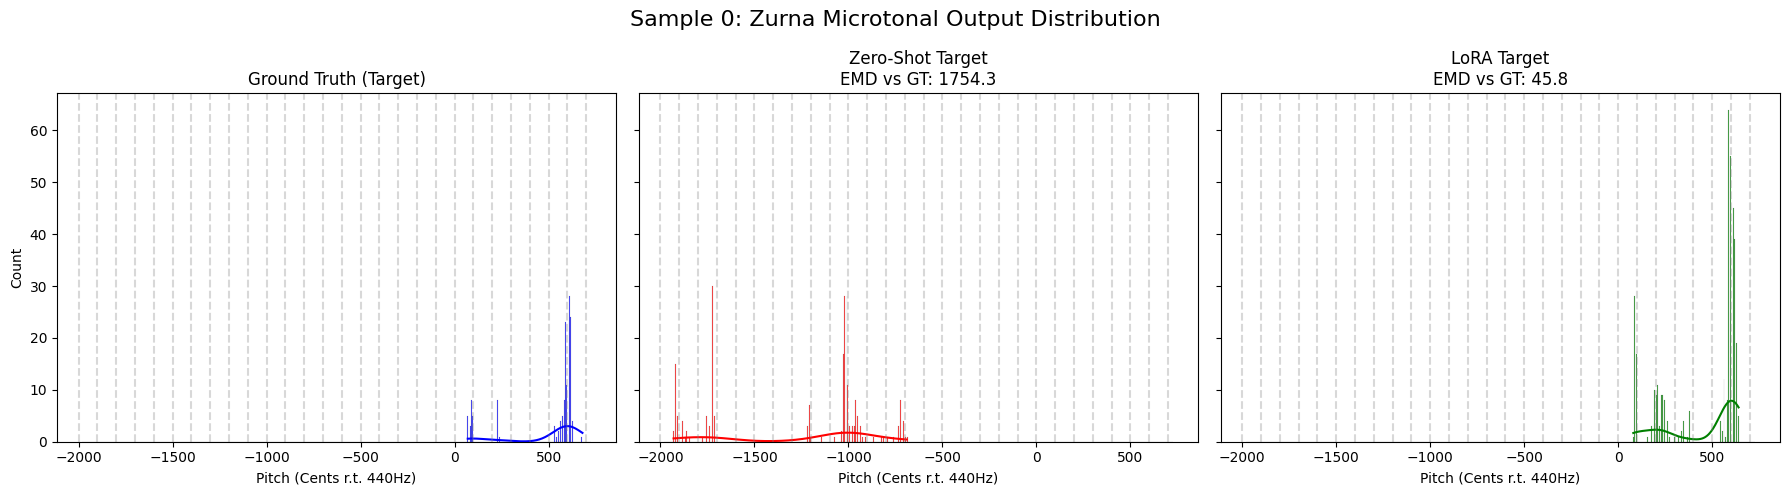


[2/5] Analyzing Mix: mixed_006.wav
Instrument: Baglama
  -> Extracting F0 with pyin (this takes a moment)...


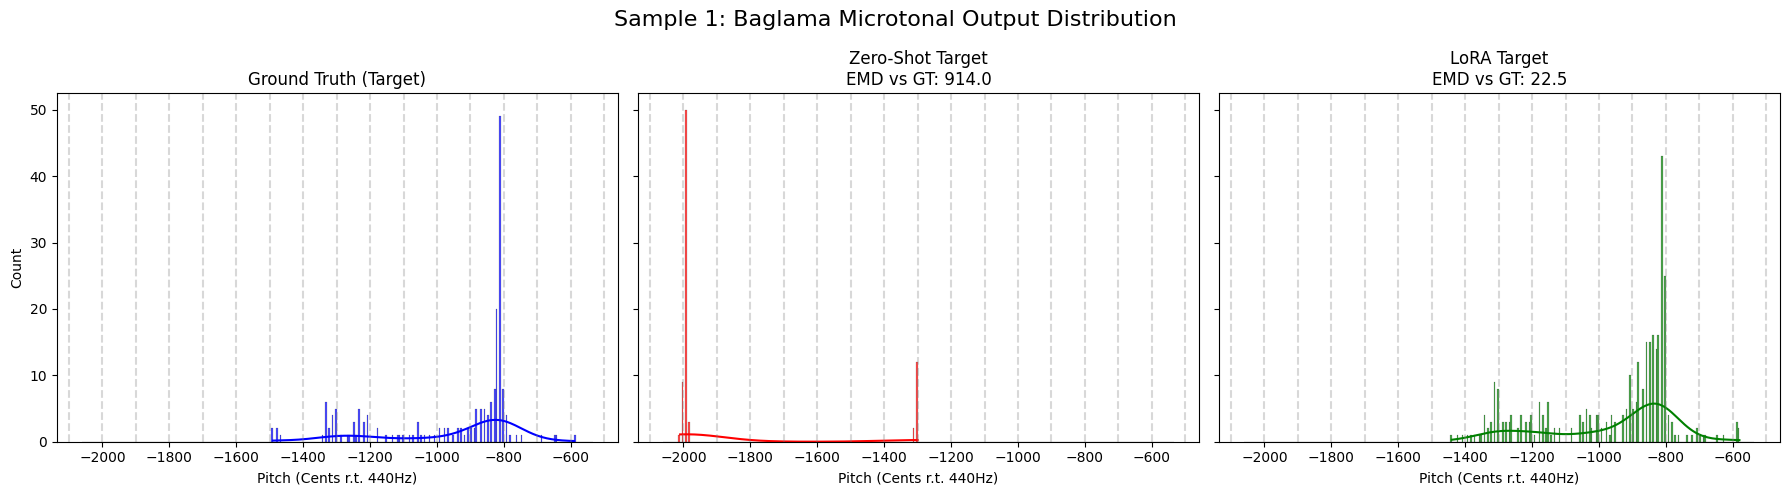


[3/5] Analyzing Mix: mixed_010.wav
Instrument: Zurna
  -> Extracting F0 with pyin (this takes a moment)...


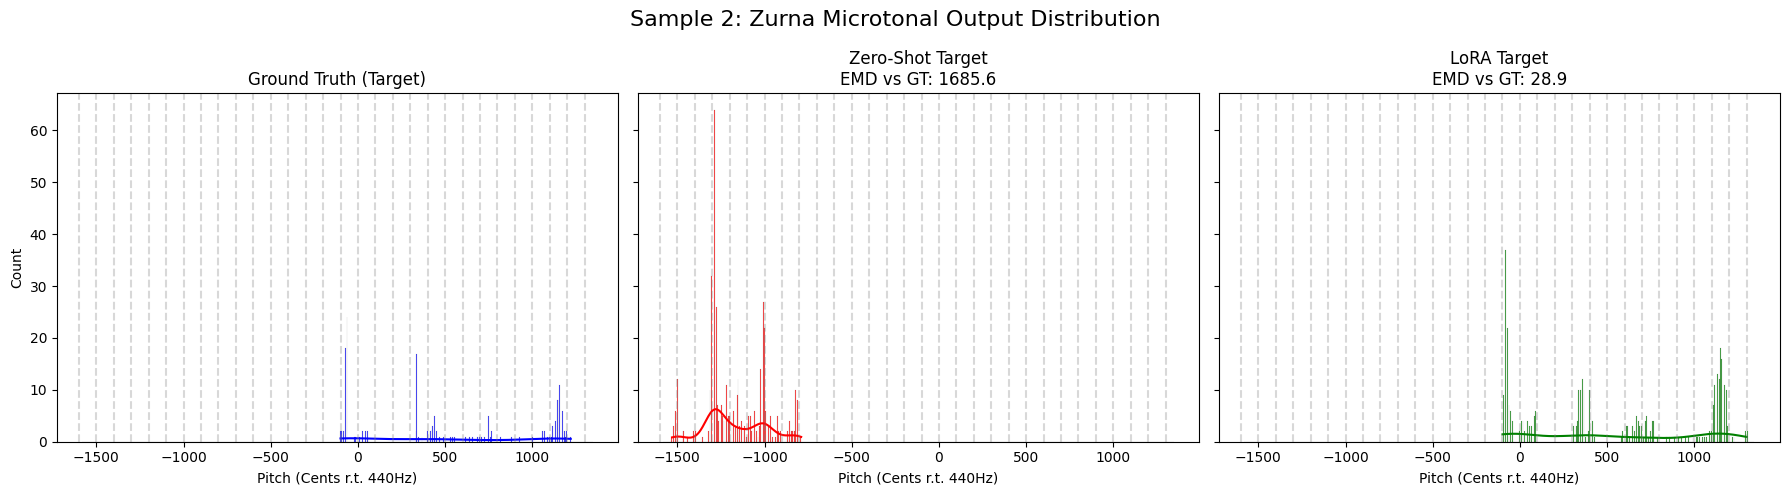


[4/5] Analyzing Mix: mixed_028.wav
Instrument: Zurna
  -> Extracting F0 with pyin (this takes a moment)...


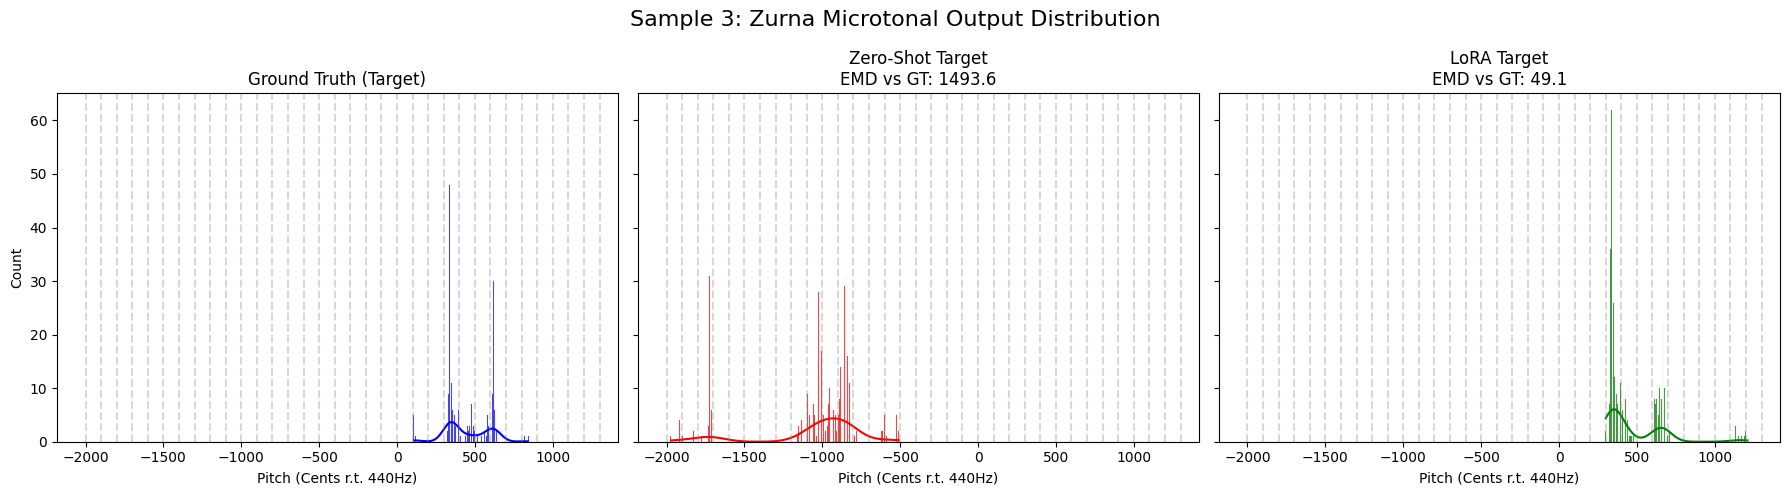


[5/5] Analyzing Mix: mixed_055.wav
Instrument: Zurna
  -> Extracting F0 with pyin (this takes a moment)...


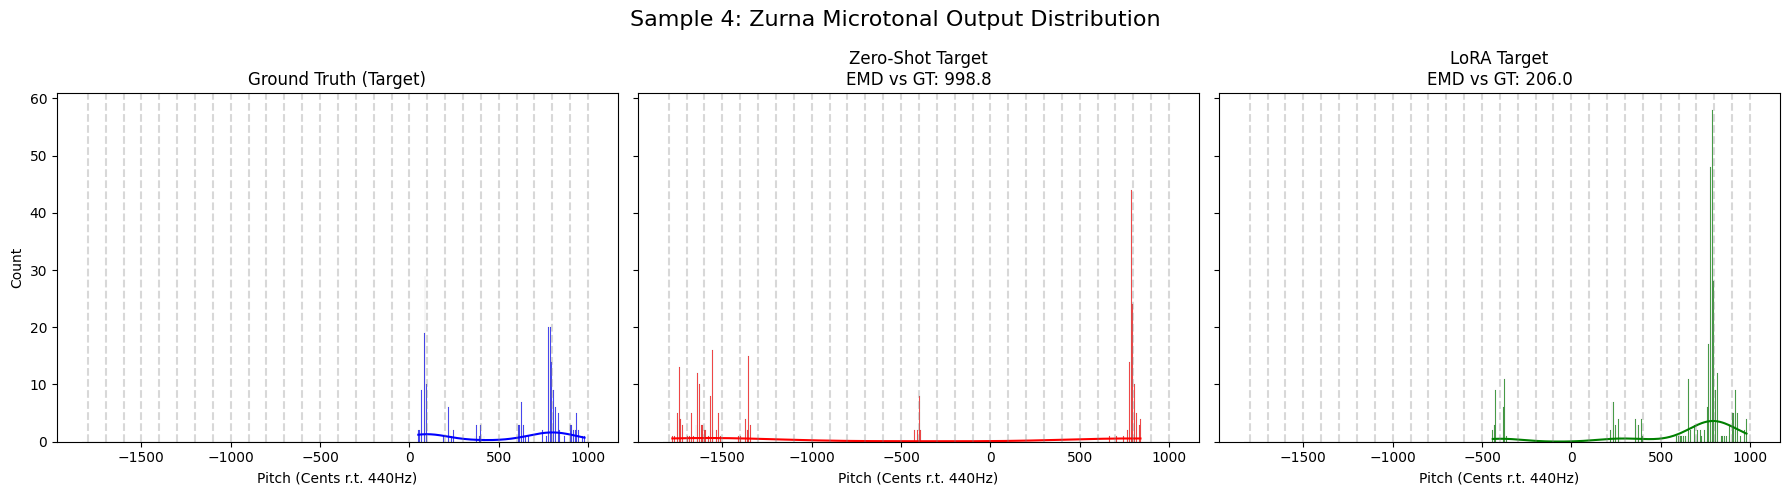


--- Evaluation Summary ---
   sample instrument  emd_zer_shot    emd_lora
0       0      zurna   1754.313063   45.759719
1       1    baglama    913.965983   22.460531
2       2      zurna   1685.561441   28.866661
3       3      zurna   1493.573716   49.066953
4       4      zurna    998.818144  206.013859

Average Earth Mover's Distance (Lower is better):
Zero-Shot Baseline: 1369.25 cents
LoRA Fine-Tuned: 70.43 cents


In [ ]:
# Run Pitch Analysis on a subset of the test outputs
NUM_EVALUATIONS = min(5, len(evaluation_pairs))

stats = []
print(f"Executing 3-Way Pitch Analysis on {NUM_EVALUATIONS} validation stems...")

for i in range(NUM_EVALUATIONS):
    pair = evaluation_pairs[i]
    print(f"\n[{i+1}/{NUM_EVALUATIONS}] Analyzing Mix: {os.path.basename(pair['mixed'])}")
    print(f"Instrument: {pair['instrument'].capitalize()}")

    y_gt, sr_gt = librosa.load(pair['ground_truth'], sr=None)
    y_zs, sr_zs = librosa.load(pair['zero_shot'], sr=None)
    y_lora, sr_lora = librosa.load(pair['lora'], sr=None)

    print("  -> Extracting F0 with pyin (this takes a moment)...")

    f0_gt = extract_f0_pyin(y_gt, sr=sr_gt)
    f0_zs = extract_f0_pyin(y_zs, sr=sr_zs)
    f0_lora = extract_f0_pyin(y_lora, sr=sr_lora)

    cents_gt = hz_to_cents(f0_gt)
    cents_zs = hz_to_cents(f0_zs)
    cents_lora = hz_to_cents(f0_lora)

    ds_zs, ds_lora = plot_and_evaluate_3way(
        cents_gt, cents_zs, cents_lora,
        title=f"Sample {i}: {pair['instrument'].capitalize()} Microtonal Output Distribution"
    )

    stats.append({
        'sample': i,
        'instrument': pair['instrument'],
        'emd_zer_shot': ds_zs,
        'emd_lora': ds_lora
    })

# Summary
if len(stats) > 0:
    import pandas as pd
    df_eval = pd.DataFrame(stats)
    print("\n--- Evaluation Summary ---")
    print(df_eval)

    avg_zs_emd = df_eval['emd_zer_shot'].mean()
    avg_lora_emd = df_eval['emd_lora'].mean()
    print(f"\nAverage Earth Mover's Distance (Lower is better):")
    print(f"Zero-Shot Baseline: {avg_zs_emd:.2f} cents")
    print(f"LoRA Fine-Tuned: {avg_lora_emd:.2f} cents")